In [1]:
# =========================
# 0. Environment & CUDA Check
# =========================

import os
import glob
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# CUDA check
try:
    import torch
    CUDA_AVAILABLE = torch.cuda.is_available()
    DEVICE = "cuda" if CUDA_AVAILABLE else "cpu"
    print("CUDA available:", CUDA_AVAILABLE)
    if CUDA_AVAILABLE:
        print("GPU name:", torch.cuda.get_device_name(0))
except Exception as e:
    CUDA_AVAILABLE = False
    DEVICE = "cpu"
    print("PyTorch / CUDA not available.")
    print("Reason:", e)

print("Device:", DEVICE)

# 注意：
# 這一版模型是 sklearn LDA，sklearn 的 LDA 本身不使用 CUDA。
# CUDA 檢查先放在前面，後續如果加入 XGBoost / GPU SVM，可以直接沿用 GPU 設定。

CUDA available: False
Device: cpu


### Import data

In [2]:
# =========================
# 1. Load Data
# =========================

# 路徑相對於 notebooks/ 資料夾；資料下載方式見 data/README.md
TRAIN_PATH = os.path.join("..", "data", "train.csv")
TEST_PATH  = os.path.join("..", "data", "test.csv")
SUBMISSION_DIR = os.path.join("..", "submissions")

def find_file(local_path, filename):
    """
    先讀 repo 內的 data/ 資料夾。
    若在 Kaggle / Colab / Linux 環境找不到，會自動搜尋常見資料夾。
    """
    if os.path.exists(local_path):
        return local_path
    
    search_patterns = [
        f"/kaggle/input/**/{filename}",
        f"/content/**/{filename}",
        f"/mnt/data/{filename}"
    ]
    
    for pattern in search_patterns:
        matches = glob.glob(pattern, recursive=True)
        if len(matches) > 0:
            return matches[0]
    
    raise FileNotFoundError(f"Cannot find {filename}. Please check the path.")

train_path = find_file(TRAIN_PATH, "train.csv")
test_path = find_file(TEST_PATH, "test.csv")

print("Train path:", train_path)
print("Test path:", test_path)

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("train shape:", train.shape)
print("test shape:", test.shape)

display(train.head())
display(test.head())

Train path: ../data/train.csv
Test path: ../data/test.csv


train shape: (7352, 563)
test shape: (2947, 562)


,id,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,1,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,STANDING
1,2,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,STANDING
2,3,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,STANDING
3,4,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,STANDING
4,5,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,STANDING


,id,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,8085,0.216993,-0.022620,-0.169512,-0.413325,-0.304652,-0.421787,-0.455183,-0.295585,-0.443094,...,-0.061779,-0.586575,-0.896732,0.271587,-0.104608,-0.862445,-0.855519,-0.840637,0.170617,0.104646
1,8345,0.208039,0.009511,-0.080870,-0.234518,0.112911,-0.344515,-0.298510,-0.002597,-0.319790,...,-0.060841,0.021949,-0.430610,0.548628,-0.282053,0.938715,0.486825,-0.800737,0.233548,-0.008213
2,9694,0.191632,-0.047057,-0.210377,-0.203679,0.312846,-0.106186,-0.238022,0.304928,-0.134192,...,-0.202073,-0.120103,-0.512378,0.140444,0.197329,-0.840004,-0.278198,-0.671754,0.312416,0.092861
3,8999,0.245636,-0.046246,-0.197446,-0.161804,-0.114983,-0.023306,-0.244775,-0.139577,-0.113590,...,0.268181,-0.183681,-0.566435,0.005166,-0.635474,0.903401,0.233172,-0.786633,0.209591,0.118039
4,9235,0.276200,-0.020466,-0.115694,-0.997035,-0.941785,-0.973809,-0.997528,-0.936443,-0.970876,...,0.406373,-0.736426,-0.927379,0.020646,0.100236,0.230791,0.642106,-0.799939,0.231660,-0.019366


In [3]:
# =========================
# 2. Basic Data Check
# =========================

TARGET_COL = "Activity"
ID_COL = "id"

print("Columns in train:", train.shape[1])
print("Columns in test:", test.shape[1])

print("\nMissing values in train:", train.isna().sum().sum())
print("Missing values in test:", test.isna().sum().sum())

print("\nDuplicated rows in train:", train.duplicated().sum())
print("Duplicated rows in test:", test.duplicated().sum())

print("\nActivity distribution:")
display(train[TARGET_COL].value_counts())

print("\nActivity proportion:")
display(train[TARGET_COL].value_counts(normalize=True).round(4))

Columns in train: 563
Columns in test: 562

Missing values in train: 0
Missing values in test: 0

Duplicated rows in train: 0
Duplicated rows in test: 0

Activity distribution:


Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


Activity proportion:


Activity
LAYING                0.1914
STANDING              0.1869
SITTING               0.1749
WALKING               0.1668
WALKING_UPSTAIRS      0.1459
WALKING_DOWNSTAIRS    0.1341
Name: proportion, dtype: float64

In [4]:
# =========================
# 3. Feature / Target Split
# =========================

# id is only an identifier for submission and should not be used as a model feature.
# All three models below use this same feature_cols setting, so none of them will see id during training.
feature_cols = [col for col in train.columns if col not in [TARGET_COL, ID_COL]]

# Ensure test column order matches training feature columns.
X = train[feature_cols].copy()
y = train[TARGET_COL].copy()

X_test = test[feature_cols].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

print()
print("First 10 feature columns:")
print(feature_cols[:10])

print()
print("Does feature_cols include id?")
print(ID_COL in feature_cols)


X shape: (7352, 561)
y shape: (7352,)
X_test shape: (2947, 561)

First 10 feature columns:
['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']

Does feature_cols include id?
False


### EDA

In [5]:
# =========================
# 4. EDA: Scaling Features
# =========================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

print("Scaled train shape:", X_scaled_df.shape)
print("Scaled test shape:", X_test_scaled_df.shape)

display(X_scaled_df.describe().T[["mean", "std", "min", "max"]].head(10))

Scaled train shape: (7352, 561)
Scaled test shape: (2947, 561)


,mean,std,min,max
tBodyAcc-mean()-X,5.160906e-16,1.000068,-18.140487,10.326608
tBodyAcc-mean()-Y,-5.508832e-17,1.000068,-24.071521,24.938779
tBodyAcc-mean()-Z,-1.411034e-16,1.000068,-15.730849,19.585288
tBodyAcc-std()-X,1.700973e-16,1.000068,-0.879336,3.577947
tBodyAcc-std()-Y,7.731695e-18,1.000068,-0.972792,2.839526
tBodyAcc-std()-Z,1.391705e-16,1.000068,-0.944079,3.833088
tBodyAcc-mad()-X,3.092678e-17,1.000068,-0.871344,3.845150
tBodyAcc-mad()-Y,-1.546339e-17,1.000068,-0.973625,3.075829
tBodyAcc-mad()-Z,-6.958525e-17,1.000068,-0.951112,3.878713
tBodyAcc-max()-X,-8.118279e-17,1.000068,-0.975917,2.697113


In [6]:
# =========================
# 5. EDA: PCA with 90% Explained Variance
# =========================

pca_90 = PCA(n_components=0.90, svd_solver="full", random_state=SEED)

X_pca_90 = pca_90.fit_transform(X_scaled)
X_test_pca_90 = pca_90.transform(X_test_scaled)

explained_var = pca_90.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

print("Original feature dimension:", X_scaled.shape[1])
print("Number of PCs for 90% explained variance:", pca_90.n_components_)
print("Cumulative explained variance:", cum_explained_var[-1])

pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_var))],
    "ExplainedVarianceRatio": explained_var,
    "CumulativeExplainedVariance": cum_explained_var
})

display(pca_summary.head(20))

Original feature dimension: 561
Number of PCs for 90% explained variance: 63
Cumulative explained variance: 0.900534506614497


,PC,ExplainedVarianceRatio,CumulativeExplainedVariance
0,PC1,0.507812,0.507812
1,PC2,0.065807,0.573619
2,PC3,0.028064,0.601683
3,PC4,0.025040,0.626722
4,PC5,0.018883,0.645605
5,PC6,0.017240,0.662845
6,PC7,0.013710,0.676555
7,PC8,0.011991,0.688546
8,PC9,0.009959,0.698505
9,PC10,0.009651,0.708156


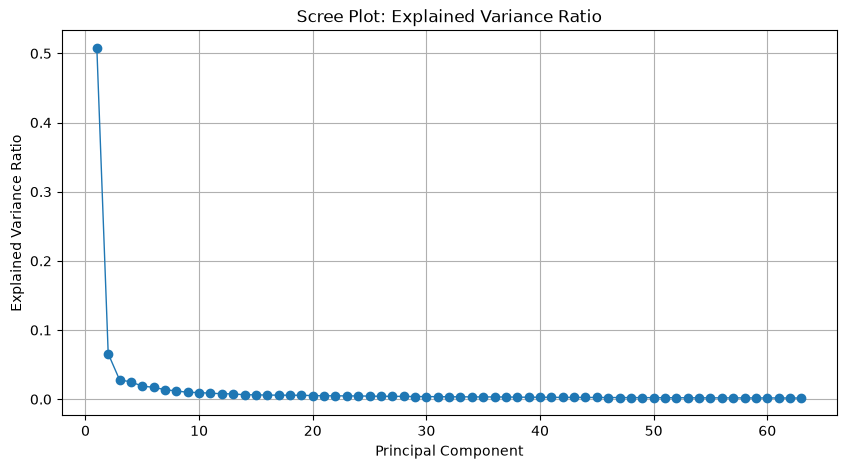

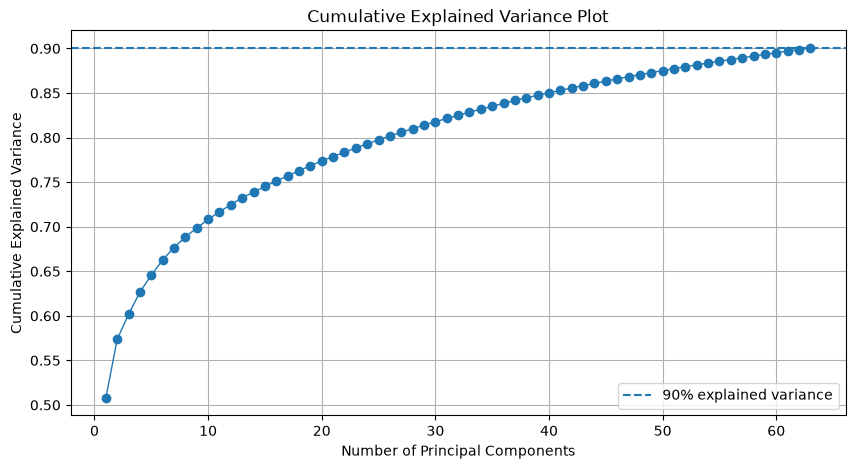

In [7]:
# =========================
# 6. EDA: Scree Plot
# =========================

plt.figure(figsize=(10, 5))
plt.plot(
    np.arange(1, len(explained_var) + 1),
    explained_var,
    marker="o",
    linewidth=1
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot: Explained Variance Ratio")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(
    np.arange(1, len(cum_explained_var) + 1),
    cum_explained_var,
    marker="o",
    linewidth=1
)
plt.axhline(y=0.90, linestyle="--", label="90% explained variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance Plot")
plt.legend()
plt.grid(True)
plt.show()

PC1 explained variance ratio: 0.5078117229128598
PC2 explained variance ratio: 0.06580680266793427
Total explained variance by PC1 + PC2: 0.5736185255807941


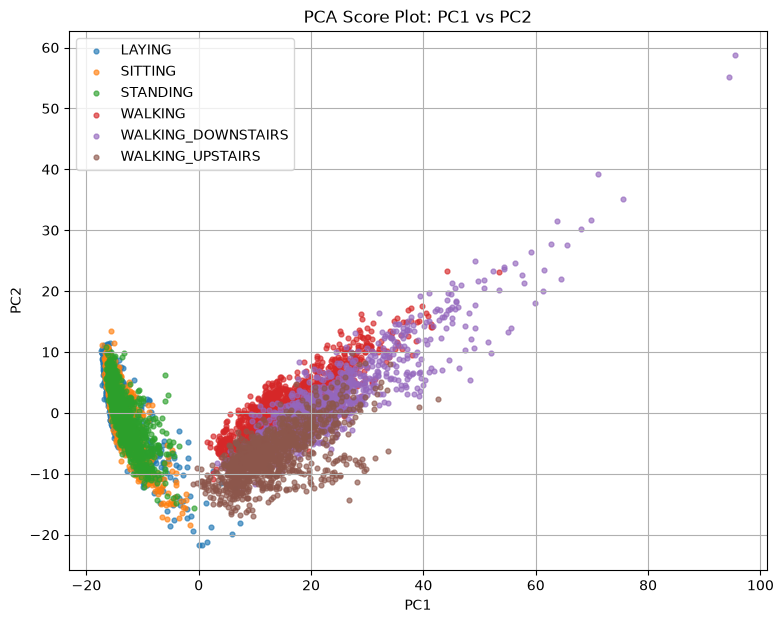

In [8]:
# =========================
# 7. EDA: PCA Score Plot
# =========================

pca_2 = PCA(n_components=2, random_state=SEED)
X_pca_2 = pca_2.fit_transform(X_scaled)

score_df = pd.DataFrame({
    "PC1": X_pca_2[:, 0],
    "PC2": X_pca_2[:, 1],
    "Activity": y.values
})

print("PC1 explained variance ratio:", pca_2.explained_variance_ratio_[0])
print("PC2 explained variance ratio:", pca_2.explained_variance_ratio_[1])
print("Total explained variance by PC1 + PC2:", pca_2.explained_variance_ratio_.sum())

plt.figure(figsize=(9, 7))

activities = sorted(score_df["Activity"].unique())

for activity in activities:
    temp = score_df[score_df["Activity"] == activity]
    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        s=12,
        alpha=0.65,
        label=activity
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Score Plot: PC1 vs PC2")
plt.legend()
plt.grid(True)
plt.show()

### Model1 : LDA with all features

In [9]:
# =========================
# 8. Model Building: LDA Baseline
# =========================

# 注意：
# 這裡依照你的要求，模型直接輸入所有特徵。
# 前面的 PCA 只用於 EDA，不放進 LDA pipeline。

lda_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage= 0.003
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

cv_scores = cross_val_score(
    lda_model,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("LDA CV accuracy scores:")
print(cv_scores)

print("\nLDA mean CV accuracy:", cv_scores.mean())
print("LDA std CV accuracy:", cv_scores.std())

LDA CV accuracy scores:
[0.97756628 0.98368457 0.97278912 0.98163265 0.97823129]

LDA mean CV accuracy: 0.9787807821973112
LDA std CV accuracy: 0.003737841752252631


OOF Accuracy: 0.9787812840043526

Classification Report:
                    precision    recall  f1-score   support

            LAYING       0.99      1.00      1.00      1407
           SITTING       0.94      0.94      0.94      1286
          STANDING       0.95      0.95      0.95      1374
           WALKING       1.00      1.00      1.00      1226
WALKING_DOWNSTAIRS       1.00      0.99      1.00       986
  WALKING_UPSTAIRS       0.99      1.00      1.00      1073

          accuracy                           0.98      7352
         macro avg       0.98      0.98      0.98      7352
      weighted avg       0.98      0.98      0.98      7352



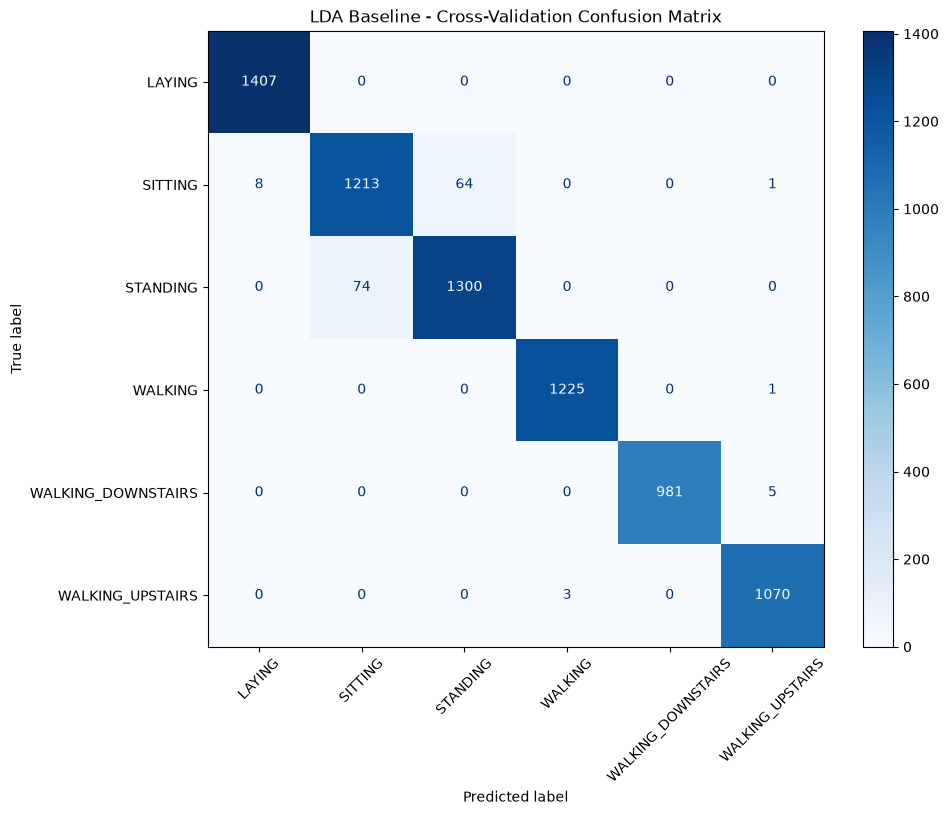

In [10]:
# =========================
# 9. CV Prediction & Confusion Matrix
# =========================

oof_pred = cross_val_predict(
    lda_model,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

oof_acc = accuracy_score(y, oof_pred)

print("OOF Accuracy:", oof_acc)
print("\nClassification Report:")
print(classification_report(y, oof_pred))

cm = confusion_matrix(y, oof_pred, labels=activities)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=activities
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)
plt.title("LDA Baseline - Cross-Validation Confusion Matrix")
plt.show()

In [11]:
# =========================
# 10. Fit Final LDA Model on Full Training Data
# =========================

lda_model.fit(X, y)

train_pred = lda_model.predict(X)
train_acc = accuracy_score(y, train_pred)

print("Final LDA training accuracy:", train_acc)

Final LDA training accuracy: 0.985038084874864


In [12]:
# =========================
# 11. Predict Test Data
# =========================

test_pred = lda_model.predict(X_test)

print("Prediction shape:", test_pred.shape)
print("\nPredicted Activity distribution:")
display(pd.Series(test_pred).value_counts())

# =========================
# 12. Create Submission CSV
# =========================

submission = pd.DataFrame({
    "id": test[ID_COL],
    "Activity": test_pred
})

print("submission shape:", submission.shape)
display(submission.head())

submission.to_csv(os.path.join(SUBMISSION_DIR, "submission.csv"), index=False)

print("Saved submission.csv")

# =========================
# 13. Check Submission File
# =========================

check_submission = pd.read_csv(os.path.join(SUBMISSION_DIR, "submission.csv"))

print(check_submission.shape)
display(check_submission.head())
display(check_submission["Activity"].value_counts())

print("Columns:", check_submission.columns.tolist())

Prediction shape: (2947,)

Predicted Activity distribution:


STANDING              561
LAYING                537
WALKING               503
WALKING_UPSTAIRS      481
SITTING               461
WALKING_DOWNSTAIRS    404
Name: count, dtype: int64

submission shape: (2947, 2)


,id,Activity
0,8085,WALKING_UPSTAIRS
1,8345,WALKING
2,9694,WALKING
3,8999,WALKING_DOWNSTAIRS
4,9235,STANDING


Saved submission.csv
(2947, 2)


,id,Activity
0,8085,WALKING_UPSTAIRS
1,8345,WALKING
2,9694,WALKING
3,8999,WALKING_DOWNSTAIRS
4,9235,STANDING


Activity
STANDING              561
LAYING                537
WALKING               503
WALKING_UPSTAIRS      481
SITTING               461
WALKING_DOWNSTAIRS    404
Name: count, dtype: int64

Columns: ['id', 'Activity']


### Model2 : SVM with all features

GPU SVM available via RAPIDS cuML: False
Using sklearn SVC on CPU. sklearn.svm.SVC does not support CUDA.


Model 2 - Linear SVM with all sensor features
CV accuracy scores:
[0.9789259  0.98844324 0.98231293 0.98707483 0.9829932 ]
Mean CV accuracy: 0.9839500178045386
Std CV accuracy: 0.0034290170499073243


OOF Accuracy: 0.983949945593036
OOF Macro F1: 0.9850491721832842

Classification Report:
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00      1407
           SITTING       0.96      0.95      0.96      1286
          STANDING       0.96      0.96      0.96      1374
           WALKING       1.00      1.00      1.00      1226
WALKING_DOWNSTAIRS       1.00      1.00      1.00       986
  WALKING_UPSTAIRS       1.00      1.00      1.00      1073

          accuracy                           0.98      7352
         macro avg       0.99      0.99      0.99      7352
      weighted avg       0.98      0.98      0.98      7352



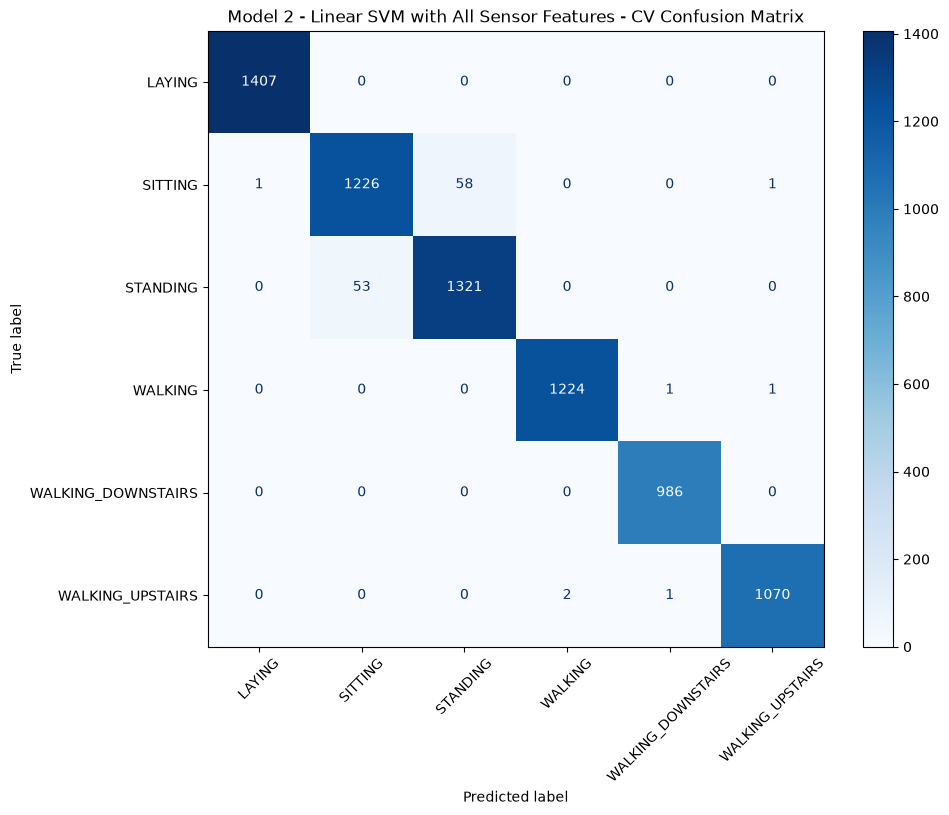

Model 2 training accuracy: 0.9985038084874864
Model 2 prediction shape: (2947,)

Model 2 predicted Activity distribution:


STANDING              569
LAYING                539
WALKING               517
WALKING_UPSTAIRS      469
SITTING               451
WALKING_DOWNSTAIRS    402
Name: count, dtype: int64

Saved model2.csv


,id,Activity
0,8085,WALKING_UPSTAIRS
1,8345,WALKING
2,9694,WALKING
3,8999,WALKING_DOWNSTAIRS
4,9235,STANDING


In [13]:
# =========================
# 14. Model 2: SVM with All Sensor Features
# =========================

from sklearn.svm import SVC
from sklearn.metrics import f1_score

try:
    from cuml.svm import SVC as cuSVC
    GPU_SVM_AVAILABLE = True
except Exception as e:
    cuSVC = None
    GPU_SVM_AVAILABLE = False
    GPU_SVM_REASON = str(e)

print("GPU SVM available via RAPIDS cuML:", GPU_SVM_AVAILABLE)
if not GPU_SVM_AVAILABLE:
    print("Using sklearn SVC on CPU. sklearn.svm.SVC does not support CUDA.")

# Model 2 uses all sensor-derived features. id is excluded in the feature split above.
svm_all = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="linear",
        C=3,
        cache_size=1000
    ))
])

svm_all_cv_scores = cross_val_score(
    svm_all,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Model 2 - Linear SVM with all sensor features")
print("CV accuracy scores:")
print(svm_all_cv_scores)
print("Mean CV accuracy:", svm_all_cv_scores.mean())
print("Std CV accuracy:", svm_all_cv_scores.std())

svm_all_oof_pred = cross_val_predict(
    svm_all,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

print("OOF Accuracy:", accuracy_score(y, svm_all_oof_pred))
print("OOF Macro F1:", f1_score(y, svm_all_oof_pred, average="macro"))
print()
print("Classification Report:")
print(classification_report(y, svm_all_oof_pred))

svm_all_cm = confusion_matrix(y, svm_all_oof_pred, labels=activities)
svm_all_disp = ConfusionMatrixDisplay(
    confusion_matrix=svm_all_cm,
    display_labels=activities
)

fig, ax = plt.subplots(figsize=(10, 8))
svm_all_disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)
plt.title("Model 2 - Linear SVM with All Sensor Features - CV Confusion Matrix")
plt.show()

svm_all.fit(X, y)
svm_all_train_pred = svm_all.predict(X)
print("Model 2 training accuracy:", accuracy_score(y, svm_all_train_pred))

test_pred_model2 = svm_all.predict(X_test)
print("Model 2 prediction shape:", test_pred_model2.shape)
print()
print("Model 2 predicted Activity distribution:")
display(pd.Series(test_pred_model2).value_counts())

model2_submission = pd.DataFrame({
    "id": test[ID_COL],
    "Activity": test_pred_model2
})

model2_submission.to_csv(os.path.join(SUBMISSION_DIR, "model2.csv"), index=False)
print("Saved model2.csv")
display(model2_submission.head())


### Model3 : SVM with 90% PCA

Model 3 - Linear SVM with 90% PCA
CV accuracy scores:
[0.9503739  0.96668933 0.95918367 0.95918367 0.95238095]
Mean CV accuracy: 0.9575623043234968
Std CV accuracy: 0.005780654818420536


OOF Accuracy: 0.9575625680087051
OOF Macro F1: 0.959573603184467

Classification Report:
                    precision    recall  f1-score   support

            LAYING       0.99      1.00      1.00      1407
           SITTING       0.90      0.89      0.90      1286
          STANDING       0.91      0.91      0.91      1374
           WALKING       0.99      0.99      0.99      1226
WALKING_DOWNSTAIRS       0.98      0.99      0.99       986
  WALKING_UPSTAIRS       0.99      0.98      0.98      1073

          accuracy                           0.96      7352
         macro avg       0.96      0.96      0.96      7352
      weighted avg       0.96      0.96      0.96      7352



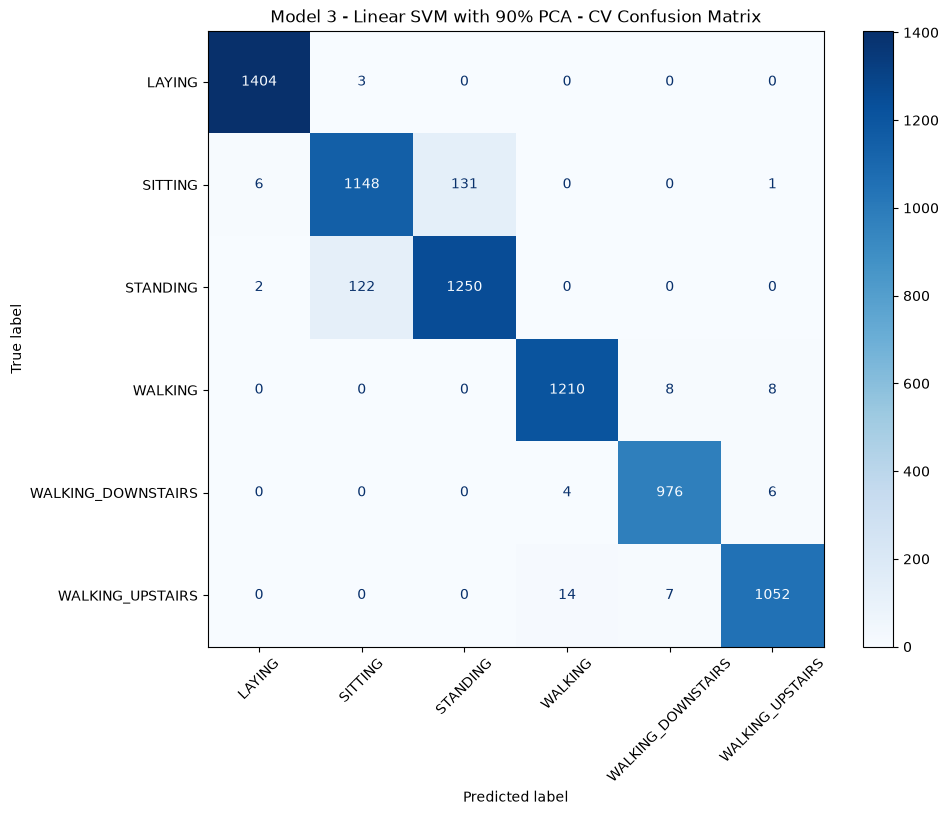

Model 3 selected PCA components: 63
Model 3 cumulative explained variance: 0.9005345066144966
Model 3 training accuracy: 0.9699401523394995
Model 3 prediction shape: (2947,)

Model 3 predicted Activity distribution:


STANDING              534
LAYING                531
WALKING               520
SITTING               495
WALKING_UPSTAIRS      452
WALKING_DOWNSTAIRS    415
Name: count, dtype: int64

Saved model3.csv


,id,Activity
0,8085,WALKING_UPSTAIRS
1,8345,WALKING
2,9694,WALKING_UPSTAIRS
3,8999,WALKING_DOWNSTAIRS
4,9235,STANDING


In [14]:
# =========================
# 15. Model 3: SVM with 90% PCA
# =========================

# PCA is inside the Pipeline to avoid data leakage during cross-validation.
# id is excluded before PCA, so PCA is fitted only on sensor-derived features.
svm_pca90 = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.90, svd_solver="full", random_state=SEED)),
    ("svm", SVC(
        kernel="linear",
        C=3,
        cache_size=1000
    ))
])

svm_pca90_cv_scores = cross_val_score(
    svm_pca90,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Model 3 - Linear SVM with 90% PCA")
print("CV accuracy scores:")
print(svm_pca90_cv_scores)
print("Mean CV accuracy:", svm_pca90_cv_scores.mean())
print("Std CV accuracy:", svm_pca90_cv_scores.std())

svm_pca90_oof_pred = cross_val_predict(
    svm_pca90,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

print("OOF Accuracy:", accuracy_score(y, svm_pca90_oof_pred))
print("OOF Macro F1:", f1_score(y, svm_pca90_oof_pred, average="macro"))
print()
print("Classification Report:")
print(classification_report(y, svm_pca90_oof_pred))

svm_pca90_cm = confusion_matrix(y, svm_pca90_oof_pred, labels=activities)
svm_pca90_disp = ConfusionMatrixDisplay(
    confusion_matrix=svm_pca90_cm,
    display_labels=activities
)

fig, ax = plt.subplots(figsize=(10, 8))
svm_pca90_disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)
plt.title("Model 3 - Linear SVM with 90% PCA - CV Confusion Matrix")
plt.show()

svm_pca90.fit(X, y)

pca_step = svm_pca90.named_steps["pca"]
print("Model 3 selected PCA components:", pca_step.n_components_)
print("Model 3 cumulative explained variance:", pca_step.explained_variance_ratio_.sum())

svm_pca90_train_pred = svm_pca90.predict(X)
print("Model 3 training accuracy:", accuracy_score(y, svm_pca90_train_pred))

test_pred_model3 = svm_pca90.predict(X_test)
print("Model 3 prediction shape:", test_pred_model3.shape)
print()
print("Model 3 predicted Activity distribution:")
display(pd.Series(test_pred_model3).value_counts())

model3_submission = pd.DataFrame({
    "id": test[ID_COL],
    "Activity": test_pred_model3
})

model3_submission.to_csv(os.path.join(SUBMISSION_DIR, "model3.csv"), index=False)
print("Saved model3.csv")
display(model3_submission.head())


### Model4 : L1 Logistic Regression with all features

Model 4 - L1 Logistic Regression with all sensor features
CV accuracy scores:
[0.97552685 0.98776343 0.97210884 0.97755102 0.97823129]
Mean CV accuracy: 0.9782362870369086
Std CV accuracy: 0.0052177120686331705


OOF Accuracy: 0.9782372143634385
OOF Macro F1: 0.97930917845441

Classification Report:
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00      1407
           SITTING       0.95      0.95      0.95      1286
          STANDING       0.95      0.95      0.95      1374
           WALKING       0.99      1.00      1.00      1226
WALKING_DOWNSTAIRS       0.99      0.99      0.99       986
  WALKING_UPSTAIRS       0.99      0.99      0.99      1073

          accuracy                           0.98      7352
         macro avg       0.98      0.98      0.98      7352
      weighted avg       0.98      0.98      0.98      7352



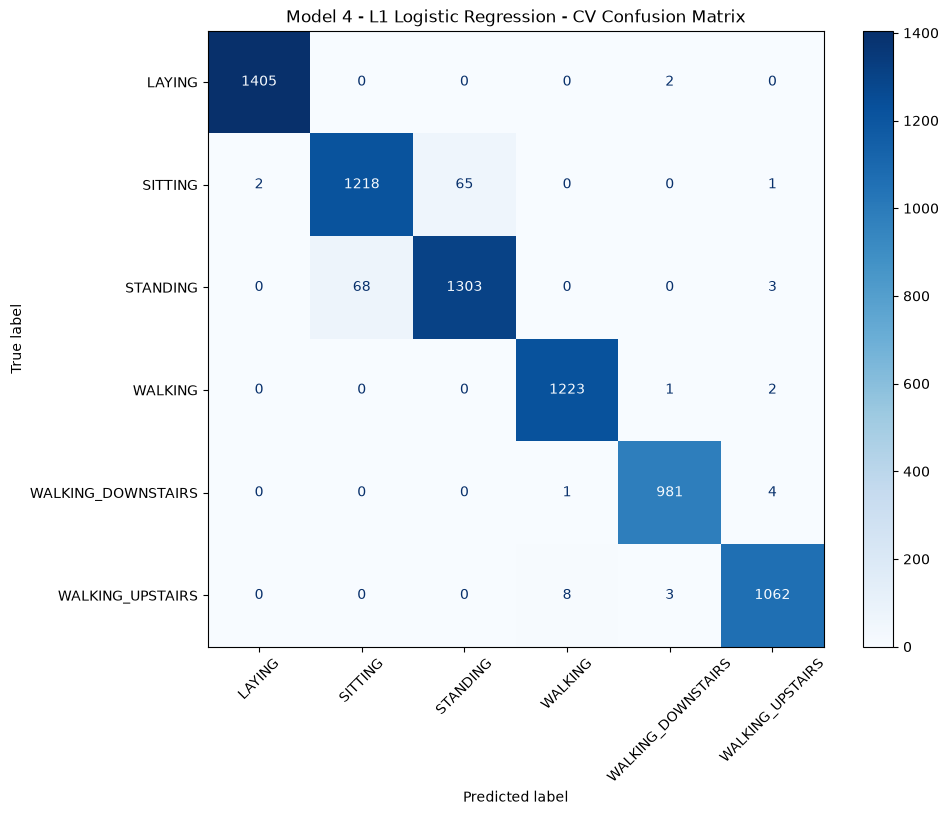

Model 4 training accuracy: 0.9880304678998912
Model 4 prediction shape: (2947,)

Model 4 predicted Activity distribution:


STANDING              567
LAYING                537
WALKING               534
WALKING_UPSTAIRS      470
SITTING               452
WALKING_DOWNSTAIRS    387
Name: count, dtype: int64

Saved model4.csv


,id,Activity
0,8085,WALKING
1,8345,WALKING
2,9694,WALKING
3,8999,WALKING_DOWNSTAIRS
4,9235,STANDING


In [15]:
# =========================
# 16. Model 4: L1 Logistic Regression with All Sensor Features
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# Logistic Regression is a linear classifier, similar in spirit to LDA but with fewer distributional assumptions.
# L1 regularization helps control coefficient size and improve generalization.
# id is excluded in feature_cols, so this model uses only sensor-derived features.
logreg_l1_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l1",
        C=0.1,
        solver="saga",
        max_iter=8000,
        random_state=SEED,
        n_jobs=-1
    ))
])

logreg_l1_cv_scores = cross_val_score(
    logreg_l1_model,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Model 4 - L1 Logistic Regression with all sensor features")
print("CV accuracy scores:")
print(logreg_l1_cv_scores)
print("Mean CV accuracy:", logreg_l1_cv_scores.mean())
print("Std CV accuracy:", logreg_l1_cv_scores.std())

logreg_l1_oof_pred = cross_val_predict(
    logreg_l1_model,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

print("OOF Accuracy:", accuracy_score(y, logreg_l1_oof_pred))
print("OOF Macro F1:", f1_score(y, logreg_l1_oof_pred, average="macro"))
print()
print("Classification Report:")
print(classification_report(y, logreg_l1_oof_pred))

logreg_l1_cm = confusion_matrix(y, logreg_l1_oof_pred, labels=activities)
logreg_l1_disp = ConfusionMatrixDisplay(
    confusion_matrix=logreg_l1_cm,
    display_labels=activities
)

fig, ax = plt.subplots(figsize=(10, 8))
logreg_l1_disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)
plt.title("Model 4 - L1 Logistic Regression - CV Confusion Matrix")
plt.show()

logreg_l1_model.fit(X, y)
logreg_l1_train_pred = logreg_l1_model.predict(X)
print("Model 4 training accuracy:", accuracy_score(y, logreg_l1_train_pred))

test_pred_model4 = logreg_l1_model.predict(X_test)

print("Model 4 prediction shape:", test_pred_model4.shape)
print()
print("Model 4 predicted Activity distribution:")
display(pd.Series(test_pred_model4).value_counts())

model4_submission = pd.DataFrame({
    "id": test[ID_COL],
    "Activity": test_pred_model4
})

model4_submission.to_csv(os.path.join(SUBMISSION_DIR, "model4.csv"), index=False)
print("Saved model4.csv")
display(model4_submission.head())


,Model,Mean CV Accuracy,Std CV Accuracy
0,Model 1\nLDA,0.978781,0.003738
1,Model 2\nSVM,0.983950,0.003429
2,Model 3\nSVM + PCA 90%,0.957562,0.005781
3,Model 4\nLogistic Regression,0.978236,0.005218


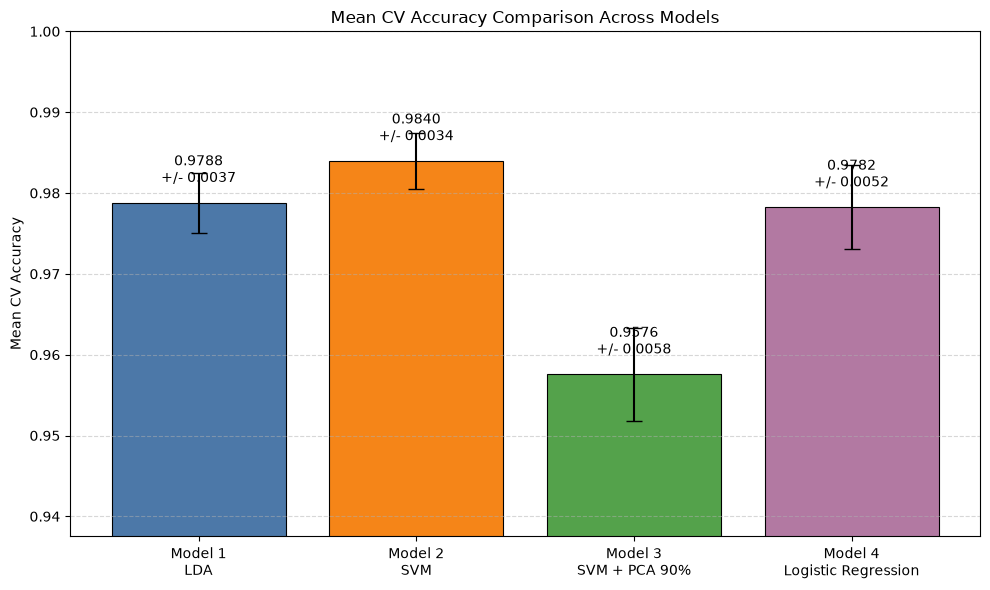

In [16]:
# =========================
# 17. Model Comparison: Mean CV Accuracy Bar Plot
# =========================

model_names = [
    "Model 1\nLDA",
    "Model 2\nSVM",
    "Model 3\nSVM + PCA 90%",
    "Model 4\nLogistic Regression"
]

cv_score_list = [
    cv_scores,
    svm_all_cv_scores,
    svm_pca90_cv_scores,
    logreg_l1_cv_scores
]

mean_cv_accuracy = [scores.mean() for scores in cv_score_list]
std_cv_accuracy = [scores.std() for scores in cv_score_list]

comparison_df = pd.DataFrame({
    "Model": model_names,
    "Mean CV Accuracy": mean_cv_accuracy,
    "Std CV Accuracy": std_cv_accuracy
})

display(comparison_df)

plt.figure(figsize=(10, 6))
bars = plt.bar(
    model_names,
    mean_cv_accuracy,
    yerr=std_cv_accuracy,
    capsize=6,
    color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"],
    edgecolor="black",
    linewidth=0.8
)

plt.ylabel("Mean CV Accuracy")
plt.title("Mean CV Accuracy Comparison Across Models")
plt.ylim(max(0, min(mean_cv_accuracy) - 0.02), min(1.0, max(mean_cv_accuracy) + 0.02))
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar, mean_acc, std_acc in zip(bars, mean_cv_accuracy, std_cv_accuracy):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f"{mean_acc:.4f}\n+/- {std_acc:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()
